In [1]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm
import os
import glob
import shutil
import time
from copy import deepcopy

from Kakapo.build_epsf import epsf_data_creation
from Kakapo.crappy_difference_image import Crappy_Difference_Imaging
from Kakapo.photometry import forced_photometry

import warnings

warnings.filterwarnings('ignore')

%matplotlib widget

In [2]:
def _tpf_addition(tpf_info, tpf_input):
    
    if tpf_input.campaign is None:
        campaign = tpf_input.quarter
        mission = 'Kepler'
        print(f"Adding TPF {tpf_input.targetid} from {mission} quarter {campaign}")
    else:
        campaign = tpf_input.campaign
        mission = 'K2'
    
    # print(tpf_info)
    tpf_info.loc[len(tpf_info)] = [mission, campaign, tpf_input.targetid, tpf_input.ra, tpf_input.dec, 
                                   tpf_input.flux.value, tpf_input.flux_err.value, tpf_input.quality, 
                                   tpf_input.pos_corr1, tpf_input.pos_corr2, tpf_input.time]
    
    return tpf_info

def _check_tpf_type(tpf_input):
    
    tpf_info = pd.DataFrame(columns=['mission', 'campaign', 'targetid', 'ra', 'dec', 'flux', 'flux_err', 
                                     'quality', 'pos_corr1', 'pos_corr2', 'time'])
    
    if isinstance(tpf_input, lk.targetpixelfile.KeplerTargetPixelFile):
        tpf_info = _tpf_addition(tpf_info, tpf_input)
    
    elif isinstance(tpf_input, str):
        tpf_input = lk.open(tpf_input, quality_bitmask = 'none')
        tpf_info = _tpf_addition(tpf_info, tpf_input)
    
    elif isinstance(tpf_input, lk.collections.TargetPixelFileCollection):
        tpf_input_list = deepcopy(tpf_input)
        
        for i in range(len(tpf_input)):
            tpf_info = _tpf_addition(tpf_info, tpf_input_list[i])
            
    elif isinstance(tpf_input, list):
        print('LIST')
        tpf_input_list = deepcopy(tpf_input)
        
        for i in range(len(tpf_input)):
            if isinstance(tpf_input_list[i], lk.targetpixelfile.KeplerTargetPixelFile):
                tpf_info = _tpf_addition(tpf_info, tpf_input_list[i])
            elif isinstance(tpf_input_list[i], str):
                tpf_input_list[i] = lk.open(tpf_input_list[i], quality_bitmask = 'none')
                tpf_info = _tpf_addition(tpf_info, tpf_input_list[i])
            else:
                raise ValueError("tpf_input must be a string, a KeplerTargetPixelFile object, or a list of KeplerTargetPixelFile objects")
    else:
        raise ValueError("tpf_input must be a string, a KeplerTargetPixelFile object, or a list of KeplerTargetPixelFile objects")
    
    return tpf_info

In [3]:
def access_tpfs():
    """
    """

    test_case = []

    lightkurve_file_folder = '/Users/zgl12/.lightkurve/cache/mastDownload/K2/'

    files = sorted(glob.glob(lightkurve_file_folder + '*/*.fits.gz'))

    for file in tqdm(files, desc='Reading TPFs'):
        tpf = lk.read(file, quality_bitmask = 'none')
        test_case.append(tpf)
        
    return test_case

In [4]:
test_case = access_tpfs()

Reading TPFs: 100%|██████████| 77/77 [00:24<00:00,  3.12it/s]


In [5]:
for i in range(len(test_case)):
     if test_case[i].campaign == 3:
        print(i, test_case[i].targetid, test_case[i].campaign, test_case[i].ra, test_case[i].dec)

4 205922648 3 337.397715 -17.325794
5 205922735 3 332.954385 -17.321714
6 205923133 3 333.80883 -17.306905
7 206010203 3 330.528675 -14.531881


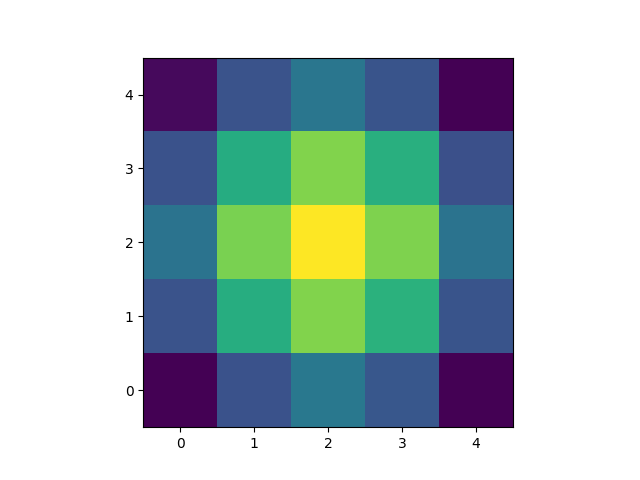

In [6]:
epsf_data = epsf_data_creation(test_case, path = '/Users/zgl12/Modules/Kakapo/', overwrite = False, stop_cond = 3000, sampling = 1)

plt.figure()
plt.imshow(epsf_data[2:-2, 2:-2], origin = 'lower')
plt.show()

In [7]:
tpf_info = _check_tpf_type(test_case)

LIST


In [8]:
tpf_info

,mission,campaign,targetid,ra,dec,flux,flux_err,quality,pos_corr1,pos_corr2,time
0,K2,101,201250050,184.188075,-3.206439,"[[[251.74258, 253.3313, 256.6473, 260.84903, 2...","[[[1.0401442, 1.0292838, 1.029111, 1.031828, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2743.3379319456144, 2743.3583639270946, 2743...."
1,K2,101,201401498,183.528090,-0.938836,"[[[256.40494, 258.93295, 261.41736, 255.38748,...","[[[1.1302468, 1.1506488, 1.1602182, 1.1171587,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2743.3377867216914, 2743.3582186715066, 2743...."
2,K2,101,201529380,181.385970,0.977168,"[[[252.18436, 252.11125, 251.63869, 254.60484,...","[[[1.3793175, 1.3698063, 1.3741267, 1.3676617,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2743.33755959633, 2743.357991491197, 2743.378..."
3,K2,15,204281574,239.409945,-22.952803,"[[[-5.505861, -6.17651, -1.4728178, 14.271063,...","[[[1.1639831, 1.1834377, 1.1613811, 1.1809866,...","[524288, 0, 0, 0, 0, 0, 0, 0, 0, 1048576, 0, 0...","[-0.41819194, -0.46132863, -0.5036242, -0.5462...","[-0.47976047, -0.50594646, -0.52866006, -0.556...","[3156.4454138697547, 3156.465846542509, 3156.4..."
4,K2,3,205922648,337.397715,-17.325794,"[[[1.0214167, -2.0332296, -1.8945229, -4.71080...","[[[1.1980397, 1.1907341, 1.1979614, 1.1719365,...","[524288, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[0.1991808, 0.18485099, 0.17464778, 0.16226713...","[-0.10820172, -0.11021814, -0.11205939, -0.112...","[2144.103027340745, 2144.123459711278, 2144.14..."
...,...,...,...,...,...,...,...,...,...,...,...
72,K2,17,251603728,204.387930,-1.239722,"[[[0.41604224, 2.0005465, -11.710611, -6.04109...","[[[1.5773939, 1.5982915, 1.601297, 1.5781254, ...","[524288, 0, 262144, 262144, 0, 262144, 262144,...","[-0.4432424, -0.46457797, -0.490276, -0.527584...","[0.09644739, 0.09865499, 0.106103584, 0.109518...","[3346.532633875351, 3346.553069475827, 3346.57..."
73,K2,17,251621981,199.678215,-0.759380,"[[[2.9166024, 1.1735541, -1.0393934, 6.262052,...","[[[1.2483796, 1.2508717, 1.2480505, 1.2596372,...","[524288, 0, 0, 0, 0, 0, 0, 0, 0, 1048576, 0, 0...","[0.48072627, 0.51507175, 0.5480485, 0.59016925...","[-0.23430885, -0.2611201, -0.2761887, -0.30602...","[3346.533064281699, 3346.553499924288, 3346.57..."
74,K2,16,251809283,136.664167,19.336111,"[[[7.383289, 20.219086, 20.843534, 15.761245, ...","[[[1.444236, 1.4395239, 1.445911, 1.4445866, 1...","[524288, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1...","[0.108842805, 0.12633751, 0.14403585, 0.157584...","[0.07590514, 0.07965818, 0.083246, 0.087505974...","[3262.4672986559744, 3262.4877339399245, 3262...."
75,K2,17,251810727,201.379497,-14.356239,"[[[-2.473333, 2.2843263, 4.788467, 1.8417712, ...","[[[1.3936951, 1.4246713, 1.4438249, 1.4214381,...","[524288, 0, 0, 0, 0, 0, 0, 0, 0, 1048576, 0, 8...","[-0.5362384, -0.5800523, -0.6104562, -0.661092...","[0.0539295, 0.061235126, 0.061996203, 0.069483...","[3346.5324227268284, 3346.552858318224, 3346.5..."


In [9]:
for i in [4, 5, 6]:
    crappy_kea = Crappy_Difference_Imaging(tpf_info.loc[i], epsf_data[2:-2, 2:-2])
    
    np.save(f"crap_diff_image_t{tpf_info.loc[i].targetid}_c{tpf_info.loc[i].campaign}.npy", crappy_kea.difference_images)